# BUILDING THE TRAINED MODEL

DATA PREPROCESSING

In [244]:
import pandas as pd

In [245]:
dataset = pd.read_csv('../dataset/upi_fraud_dataset.csv', index_col = 0)

In [246]:
dataset.head()

,trans_hour,trans_day,trans_month,trans_year,category,upi_number,age,trans_amount,state,zip,fraud_risk
0,0,1,1,2024,12,9957000001,33,66.21,22,49879,0
1,1,1,1,2024,3,9957000002,15,55.81,14,62668,0
2,3,1,1,2024,8,9957000003,60,8.68,4,96037,0
3,6,1,1,2024,4,9957000004,44,89.52,40,29911,0
4,6,1,1,2024,0,9957000005,72,1.90,38,16421,0


In [247]:
# Verify the number of columns
print(f"Number of columns: {dataset.shape[1]}")
print(f"Column names: {dataset.columns.tolist()}")

Number of columns: 11
Column names: ['trans_hour', 'trans_day', 'trans_month', 'trans_year', 'category', 'upi_number', 'age', 'trans_amount', 'state', 'zip', 'fraud_risk']


In [248]:
import numpy as np

In [249]:
X = dataset.iloc[:, :10].values
y = dataset.iloc[:, 10].values

In [250]:
from sklearn.model_selection import train_test_split

In [251]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.15, random_state = 0)

In [252]:
x_train.shape

(2266, 10)

In [253]:
x_test.shape

(400, 10)

In [254]:
fraud = np.count_nonzero(y_train == 1)
valid = np.count_nonzero(y_train == 0)

In [255]:
print('Fraud cases in training data =', fraud)
print('Valid cases in training data =', valid)

Fraud cases in training data = 1348
Valid cases in training data = 918


In [256]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [257]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [258]:
x_train[ : 5]

array([[ 0.23401555, -0.89664893, -0.04702564,  0.0602433 ,  0.68096147,
         0.84035287, -0.7458344 , -0.45791225, -1.64639185,  0.82523264],
       [-0.92994106,  0.66100707, -0.04702564, -1.24483613, -0.3824002 ,
        -0.2725867 , -0.73831661,  1.03866827, -0.4058421 ,  0.82523264],
       [-1.02693745,  2.53019426, -0.04702564,  0.32125918, -0.38240085,
         1.6353097 ,  1.19739271, -0.31538077,  0.32896382,  0.82523264],
       [ 0.91299024, -0.89664893, -0.04702564, -1.24483613, -1.11969157,
        -0.37858094, -0.63932854, -0.24411503,  0.5966091 , -1.21177951],
       [ 0.42800832, -0.89664893, -0.04702564, -1.76686789, -1.11969169,
        -0.80255792,  0.10895034,  1.18119975,  1.37176053,  0.82523264]])

In [259]:
x_test[ : 5]

array([[-1.02693745,  0.66100707, -0.04702564, -1.50585201, -0.38240103,
        -0.80255792, -0.49438092, -0.24411503,  0.60587057,  0.82523264],
       [ 1.68896132, -0.89664893, -0.04702564, -0.72280436, -0.93972315,
         0.09839316, -0.10421848, -1.66942982,  1.78976412,  0.82523264],
       [ 0.33101193, -0.27358653, -0.04702564, -1.24483613, -0.38240071,
        -0.96154929, -0.56298363,  0.46854236, -1.33247671, -1.21177951],
       [-1.22093022,  0.66100707, -0.04702564,  1.10430683,  1.8381786 ,
         0.94634711,  1.1613746 , -0.24411503,  0.62521842,  0.82523264],
       [-1.02693745, -0.27358653, -0.04702564, -0.20077259, -0.38240113,
        -0.21958958, -0.56502578, -0.67170947,  0.8568677 , -1.21177951]])

LOGISTIC REGRESSION (LR)

In [260]:
from sklearn.linear_model import LogisticRegression
LR_model = LogisticRegression(random_state = 0)
LR_model.fit(x_train, y_train)

LogisticRegression(random_state=0)

In [261]:
y_pred = LR_model.predict(x_test)

In [262]:
from sklearn.metrics import accuracy_score

In [263]:
acc_lr = accuracy_score(y_test, y_pred)

In [264]:
print(acc_lr)

1.0


K-NEAREST NEIGHBORS (KNN)

In [265]:
from sklearn.neighbors import KNeighborsClassifier
KNN_model = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
KNN_model.fit(x_train, y_train)

KNeighborsClassifier()

In [266]:
y_pred = KNN_model.predict(x_test)

In [267]:
acc_knn = accuracy_score(y_test, y_pred)

In [268]:
print(acc_knn)

1.0


SUPPORT VECTOR MACHINE (SVM)

In [269]:
from sklearn.svm import SVC
SVM_model = SVC(kernel = 'linear', random_state = 0)
SVM_model.fit(x_train, y_train)

SVC(kernel='linear', random_state=0)

In [270]:
y_pred = SVM_model.predict(x_test)

In [271]:
acc_svm = accuracy_score(y_test, y_pred)

In [272]:
print(acc_svm)

1.0


NAIVE BAYES (NB)

In [273]:
from sklearn.naive_bayes import GaussianNB
NB_model = GaussianNB()
NB_model.fit(x_train, y_train)

GaussianNB()

In [274]:
y_pred = NB_model.predict(x_test)

In [275]:
acc_nb = accuracy_score(y_test, y_pred)

In [276]:
print(acc_nb)

1.0


DECISION TREE (DT)

In [277]:
from sklearn.tree import DecisionTreeClassifier
DT_model = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
DT_model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [278]:
y_pred = DT_model.predict(x_test)

In [279]:
acc_dt = accuracy_score(y_test, y_pred)

In [280]:
print(acc_dt)

1.0


RANDOM FOREST (RF)

In [281]:
from sklearn.ensemble import RandomForestClassifier
RF_model = RandomForestClassifier()
RF_model.fit(x_train, y_train)

RandomForestClassifier()

In [282]:
y_pred = RF_model.predict(x_test)

In [283]:
acc_rf = accuracy_score(y_test, y_pred)

In [284]:
print(acc_rf)

1.0


CONVOLUTIONAL NEURAL NETWORK (CNN)

In [285]:
import tensorflow as tf

In [286]:
CNN_model = tf.keras.models.Sequential()

In [287]:
CNN_model.add(tf.keras.layers.Dense(64, input_dim = 10, activation = 'relu'))
CNN_model.add(tf.keras.layers.Dense(128, activation = 'relu'))
CNN_model.add(tf.keras.layers.Dense(1, activation = 'sigmoid'))

In [288]:
CNN_model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [289]:
CNN_model.fit(x_train, y_train, batch_size = 32, epochs = 200)

Epoch 1/200
71/71 [==============================] - 1s 2ms/step - loss: 0.2700 - accuracy: 0.9484
Epoch 2/200
71/71 [==============================] - 0s 2ms/step - loss: 0.0158 - accuracy: 0.9991
Epoch 3/200
71/71 [==============================] - 0s 2ms/step - loss: 0.0054 - accuracy: 0.9996
Epoch 4/200
71/71 [==============================] - 0s 2ms/step - loss: 0.0021 - accuracy: 0.9996
Epoch 5/200
71/71 [==============================] - 0s 2ms/step - loss: 9.5377e-04 - accuracy: 1.0000
Epoch 6/200
71/71 [==============================] - 0s 2ms/step - loss: 5.9233e-04 - accuracy: 1.0000
Epoch 7/200
71/71 [==============================] - 0s 2ms/step - loss: 4.1467e-04 - accuracy: 1.0000
Epoch 8/200
71/71 [==============================] - 0s 2ms/step - loss: 3.0647e-04 - accuracy: 1.0000
Epoch 9/200
71/71 [==============================] - 0s 2ms/step - loss: 2.3624e-04 - accuracy: 1.0000
Epoch 10/200
71/71 [==============================] - 0s 2ms/step - loss: 1.8744e-04 - ac

71/71 [==============================] - 0s 1ms/step - loss: 1.0214e-06 - accuracy: 1.0000
Epoch 81/200
71/71 [==============================] - 0s 1ms/step - loss: 9.7636e-07 - accuracy: 1.0000
Epoch 82/200
71/71 [==============================] - 0s 1ms/step - loss: 9.3347e-07 - accuracy: 1.0000
Epoch 83/200
71/71 [==============================] - 0s 1ms/step - loss: 8.9270e-07 - accuracy: 1.0000
Epoch 84/200
71/71 [==============================] - 0s 1ms/step - loss: 8.5383e-07 - accuracy: 1.0000
Epoch 85/200
71/71 [==============================] - 0s 1ms/step - loss: 8.1690e-07 - accuracy: 1.0000
Epoch 86/200
71/71 [==============================] - 0s 2ms/step - loss: 7.8161e-07 - accuracy: 1.0000
Epoch 87/200
71/71 [==============================] - 0s 1ms/step - loss: 7.4792e-07 - accuracy: 1.0000
Epoch 88/200
71/71 [==============================] - 0s 1ms/step - loss: 7.1579e-07 - accuracy: 1.0000
Epoch 89/200
71/71 [==============================] - 0s 1ms/step - loss: 6.8

71/71 [==============================] - 0s 1ms/step - loss: 4.2347e-08 - accuracy: 1.0000
Epoch 159/200
71/71 [==============================] - 0s 1ms/step - loss: 4.0813e-08 - accuracy: 1.0000
Epoch 160/200
71/71 [==============================] - 0s 2ms/step - loss: 3.9357e-08 - accuracy: 1.0000
Epoch 161/200
71/71 [==============================] - 0s 2ms/step - loss: 3.7933e-08 - accuracy: 1.0000
Epoch 162/200
71/71 [==============================] - 0s 2ms/step - loss: 3.6582e-08 - accuracy: 1.0000
Epoch 163/200
71/71 [==============================] - 0s 2ms/step - loss: 3.5301e-08 - accuracy: 1.0000
Epoch 164/200
71/71 [==============================] - 0s 2ms/step - loss: 3.4053e-08 - accuracy: 1.0000
Epoch 165/200
71/71 [==============================] - 0s 2ms/step - loss: 3.2864e-08 - accuracy: 1.0000
Epoch 166/200
71/71 [==============================] - 0s 2ms/step - loss: 3.1721e-08 - accuracy: 1.0000
Epoch 167/200
71/71 [==============================] - 0s 2ms/step - 

In [290]:
loss, acc_cnn = CNN_model.evaluate(x_train, y_train, verbose = 0)

In [291]:
print(acc_cnn)

1.0


In [292]:
y_pred = CNN_model.predict(x_test)
y_pred[y_pred <= 0.5] = 0
y_pred[y_pred > 0.5] = 1

13/13 [==============================] - 0s 1ms/step


ACCURACY COMPARISON OF ALL THE MODELS

In [293]:
scores = [acc_lr * 100,
          acc_knn * 100,
          acc_svm * 100,
          acc_nb * 100,
          acc_dt * 100,
          acc_rf * 100,
          acc_cnn * 100]

In [294]:
names = ["Logistic Regression",
        "K-Nearest Neighbors",
        "Support Vector Machine",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest",
        "Convolutional Neural Network"]

In [295]:
df = pd.DataFrame()
df['Algorithm Name'] = names
df['Accuracy Score (%)'] = scores
df = df.sort_values('Accuracy Score (%)', ascending = False)

In [296]:
df

,Algorithm Name,Accuracy Score (%)
0,Logistic Regression,100.0
1,K-Nearest Neighbors,100.0
2,Support Vector Machine,100.0
3,Naive Bayes,100.0
4,Decision Tree,100.0
5,Random Forest,100.0
6,Convolutional Neural Network,100.0


In [297]:
import matplotlib.pyplot as plt
import seaborn as sns

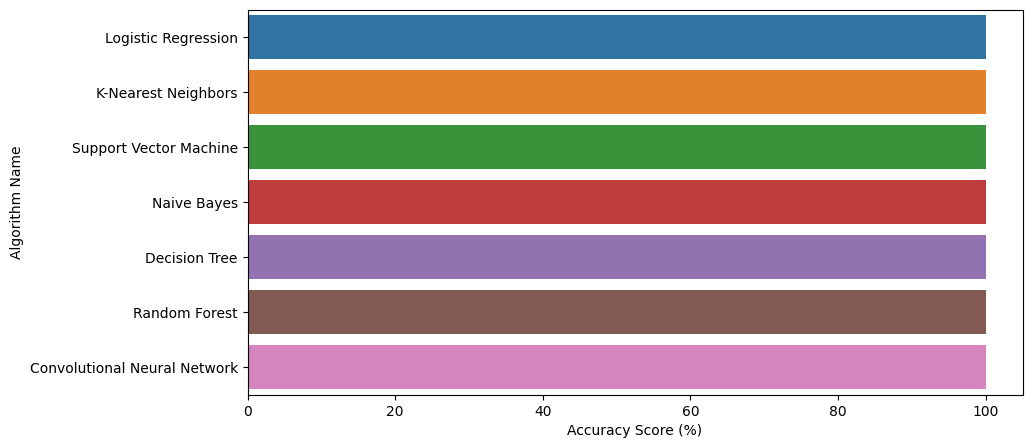

In [298]:
fig = plt.subplots(figsize = (10, 5))
ax = sns.barplot(x = "Accuracy Score (%)", y = "Algorithm Name", data = df)

SAVING THE BEST TRAINED MODEL

In [299]:
import os.path

In [301]:
if os.path.isfile('../model/project_model2.h5') is False:
    CNN_model.save('../model/project_model2.h5')

C:\Users\User\anaconda3\envs\Project\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
